# Ridge, Lasso, and Elastic Net Regression: Applications in Finance


Basado en el [artículo](https://medium.com/@filipstcu/ridge-lasso-and-elastic-net-regression-applications-in-finance-f64ca226507b)


## Introduction to Regularization
En problemas financieros, los modelos suelen incluir muchas variables explicativas que pueden estar correlacionadas entre sí (multicolinealidad), lo que dificulta la estimación precisa de los coeficientes y puede llevar a un modelo que se ajusta demasiado a los datos de entrenamiento pero generaliza mal (sobreajuste).

Las técnicas de regularización introducen una penalización al tamaño de los coeficientes en la función de coste, lo que:

Reduce la varianza del modelo.

Favorece soluciones más estables.

Mejora su capacidad de generalización.

**Tipos principales:**

* **Ridge (L2):** penaliza los coeficientes grandes añadiendo una penalización $L_2 \lambda * sum(\beta^2)$ , pero no los reduce a cero.

* **Lasso (L1):** puede reducir algunos coeficientes exactamente a cero añadiendo una penalización $L_1 \lambda * sum(|\beta|)$ , útil para **selección de variables**.

* **Elastic Net:** combina L1 y L2, útil cuando hay muchas variables correlacionadas y se busca un equilibrio entre selección y regularización.


**Ridge es preferido cuando el objetivo es reducir la varianza en presencia de multicolinealidad, mientras que Lasso es más útil cuando se busca selección de variables.**

## Regularización en Finanzas: Ridge, Lasso y Elastic Net

En una regresión lineal múltiple, estimamos los coeficientes $ \beta $ minimizando el Error Cuadrático Medio (MSE):

$$
\min \sum (y_i - X_i^T \beta)^2
$$

Sin embargo, en datos financieros, la colinealidad y la presencia de variables irrelevantes suelen aumentar la varianza de las predicciones.

La **regularización** añade una penalización a la función de pérdida para reducir los coeficientes y mejorar la capacidad de generalización.

---

### 1-Regresión Ridge (L2)

Añade una penalización L2:

$$
\min \sum (y_i - X_i^T \beta)^2 + \lambda \sum \beta_j^2
$$

- $ \lambda $: controla la intensidad de la regularización.  
- Si $ \lambda \to 0 $: se aproxima a OLS.  
- Si $ \lambda \to \infty $: los coeficientes se reducen hacia cero.

**Aplicaciones:**
- Estabiliza modelos factoriales con factores correlacionados (por ejemplo, Fama-French).
- Mejora la estimación de matrices de covarianza en optimización de carteras.
- Útil para modelar curvas de tipos con vencimientos colineales.

---

### 2- Regresión Lasso (L1)

Añade una penalización L1:

$$
\min \sum (y_i - X_i^T \beta)^2 + \lambda \sum |\beta_j|
$$

- Impone **esparsidad**: algunos coeficientes se vuelven exactamente cero.

**Aplicaciones:**
- Selección de variables en modelos de trading.
- Carteras esparsas → menos activos, menores costes.
- Selecciona indicadores macroeconómicos clave en modelos de predicción.

---

### 3- Elastic Net (L1 + L2)

Combina ambas penalizaciones:

$$
\min \sum (y_i - X_i^T \beta)^2 + \lambda_1 \sum |\beta_j| + \lambda_2 \sum \beta_j^2
$$

O, con un parámetro de mezcla $ \alpha $:

$$
\min \sum (y_i - X_i^T \beta)^2 + \lambda \left[ \alpha \sum |\beta_j| + (1 - \alpha) \sum \beta_j^2 \right]
$$

- $ \alpha = 1 $: equivalente a Lasso  
- $ \alpha = 0 $: equivalente a Ridge

**Aplicaciones:**
- Identificación de grupos de factores relevantes en selección de acciones.
- Útil en modelos de valoración con muchos activos o datos alternativos.
- Reduce el sobreajuste en modelos de riesgo crediticio.

# Python Implementation

In [18]:
#!pip install yfinance PyPortfolioOpt scikit-learn matplotlib

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt import risk_models, expected_returns
import warnings
warnings.filterwarnings('ignore')


# Configuramos el estilo de las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")


In [5]:
# Definimos las fechas para obtener datos de 5 años
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Tickers de las Magnificent Seven
mag_seven = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'NVDA']
benchmark = ['QQQ']

# Descargamos los datos históricos
tickers = mag_seven + benchmark
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Calculamos los rendimientos diarios
returns = np.log(data).diff().dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  8 of 8 completed


In [6]:
# Dividimos en conjunto de entrenamiento (70%) y prueba (30%) para evaluación
train_size = int(len(returns) * 0.7)
returns_train = returns.iloc[:train_size]
returns_test = returns.iloc[train_size:]

print(f"Período de entrenamiento: {returns_train.index[0]} a {returns_train.index[-1]}")
print(f"Período de prueba: {returns_test.index[0]} a {returns_test.index[-1]}")


Período de entrenamiento: 2020-04-01 00:00:00 a 2023-09-26 00:00:00
Período de prueba: 2023-09-27 00:00:00 a 2025-03-28 00:00:00


In [7]:
# 1. Implementación del HRP (Hierarchical Risk Parity)
# Aplicamos HRP para obtener pesos usando datos de entrenamiento
hrp_opt = HRPOpt(returns_train[mag_seven])
hrp_weights = hrp_opt.optimize()

In [ ]:
# 2. Implementación de modelos de regresión regularizada

# Función para entrenar modelos y obtener pesos
def get_reg_weights(model, X, y, assets):
    # Entrenamos el modelo
    model.fit(X, y)

    # Convertimos los coeficientes a pesos positivos
    coefs = np.abs(model.coef_)

    # Si todos son cero, asignamos pesos iguales
    if np.sum(coefs) == 0:
        weights = np.ones(len(assets)) / len(assets)
    else:
        # Normalizamos para asegurar que sumen 1
        weights = coefs / np.sum(coefs)

    return pd.Series(weights, index=assets)

In [9]:

# Preparamos datos para regresión
X_train = returns_train[mag_seven].values
y_train = returns_train['QQQ'].values
# Estandarizamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [19]:
# Creamos instancias de los modelos con diferentes niveles de regularización
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)

In [11]:
# Obtenemos pesos para cada modelo
ridge_weights = get_reg_weights(ridge, X_train_scaled, y_train, mag_seven)
lasso_weights = get_reg_weights(lasso, X_train_scaled, y_train, mag_seven)
elastic_weights = get_reg_weights(elastic, X_train_scaled, y_train, mag_seven)

In [13]:
# 3. Creamos una cartera combinada (fusión de los tres modelos de regresión)
# Primero evaluamos el desempeño de cada modelo en el conjunto de entrenamiento
def calculate_portfolio_performance(returns, weights):
    portfolio_returns = (returns * weights).sum(axis=1)
    cumulative_returns = (1 + portfolio_returns).cumprod()
    sharpe_ratio = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)  # Anualizado
    volatility = portfolio_returns.std() * np.sqrt(252)  # Anualizada
    return portfolio_returns, cumulative_returns, sharpe_ratio, volatility

In [14]:
# Evaluamos modelos en el conjunto de entrenamiento
model_names = ['Ridge', 'Lasso', 'ElasticNet']
model_weights = [ridge_weights, lasso_weights, elastic_weights]
model_sharpes = []

for name, weights in zip(model_names, model_weights):
    _, _, sharpe, _ = calculate_portfolio_performance(returns_train[mag_seven], weights)
    model_sharpes.append(sharpe)

# Normalizar los Sharpe ratios para usarlos como pesos (cuanto mayor sharpe, mayor peso)
if sum(model_sharpes) > 0:
    model_importance = [max(0, s) for s in model_sharpes]  # Aseguramos que sean no negativos
    model_importance = [w / sum(model_importance) if sum(model_importance) > 0 else 1/len(model_importance) for w in model_importance]
else:
    # Si todos los Sharpe son negativos o cero, usamos pesos iguales
    model_importance = [1/len(model_sharpes)] * len(model_sharpes)

print("\nPonderación de modelos según Sharpe ratio:")
for name, importance in zip(model_names, model_importance):
    print(f"{name}: {importance:.4f}")

# Crear la cartera combinada como una media ponderada
combined_weights = pd.Series(0, index=mag_seven)
for i, weights in enumerate(model_weights):
    combined_weights += weights * model_importance[i]

# Asegurar que los pesos sumen 1
combined_weights = combined_weights / combined_weights.sum()


Ponderación de modelos según Sharpe ratio:
Ridge: 0.3429
Lasso: 0.3180
ElasticNet: 0.3391


In [15]:
# 4. Evaluación de todas las carteras en el conjunto de prueba
all_weights = {
    'HRP': hrp_weights,
    'Ridge': ridge_weights,
    'Lasso': lasso_weights,
    'ElasticNet': elastic_weights,
    'Combinada': combined_weights,
}

print("\nDistribución de pesos de cada cartera:")
weights_df = pd.DataFrame(all_weights)
print(weights_df)

# Evaluamos todas las carteras en el conjunto de prueba
results = {}
for name, weights in all_weights.items():
    port_returns, cum_returns, sharpe, vol = calculate_portfolio_performance(returns_test[mag_seven], weights)
    results[name] = {
        'returns': port_returns,
        'cumulative': cum_returns,
        'sharpe': sharpe,
        'volatility': vol,
        'weights': weights
    }

# Calculamos el rendimiento del benchmark en el conjunto de prueba
benchmark_returns = returns_test['QQQ']
benchmark_cum_returns = (1 + benchmark_returns).cumprod()
benchmark_sharpe = benchmark_returns.mean() / benchmark_returns.std() * np.sqrt(252)
benchmark_vol = benchmark_returns.std() * np.sqrt(252)

results['QQQ'] = {
    'returns': benchmark_returns,
    'cumulative': benchmark_cum_returns,
    'sharpe': benchmark_sharpe,
    'volatility': benchmark_vol,
    'weights': pd.Series(1.0, index=['QQQ'])
}


Distribución de pesos de cada cartera:
            HRP     Ridge     Lasso  ElasticNet  Combinada
AAPL   0.195528  0.206635  0.304006    0.279249   0.262224
AMZN   0.173007  0.121176  0.000000    0.110749   0.079102
GOOGL  0.164496  0.121662  0.000000    0.115952   0.081032
META   0.108256  0.085602  0.000000    0.000000   0.029352
MSFT   0.196447  0.174734  0.653771    0.291303   0.366612
NVDA   0.069038  0.179882  0.042223    0.202747   0.143854
TSLA   0.093228  0.110309  0.000000    0.000000   0.037824


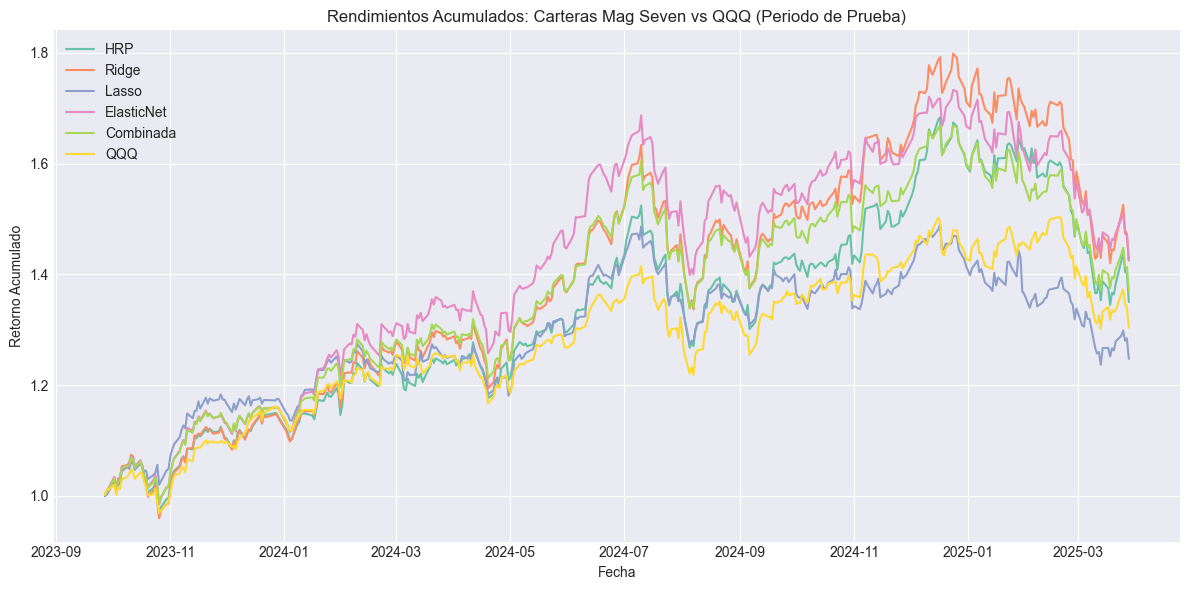

In [20]:
# 5. Visualizaciones de los resultados
# Rendimientos acumulados
plt.figure(figsize=(12, 6))
for name, result in results.items():
    plt.plot(result['cumulative'], label=name)
plt.title('Rendimientos Acumulados: Carteras Mag Seven vs QQQ (Periodo de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Retorno Acumulado')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_returns_test.png')
plt.show()

In [21]:
# Comparativa de métricas
metrics = pd.DataFrame({
    'Sharpe Ratio': [results[model]['sharpe'] for model in results],
    'Volatilidad Anualizada (%)': [results[model]['volatility'] * 100 for model in results],
    'Retorno Final (%)': [(results[model]['cumulative'].iloc[-1] - 1) * 100 for model in results]
}, index=results.keys())

print("\nComparativa de Métricas de Rendimiento (Periodo de Prueba):")
print(metrics)


Comparativa de Métricas de Rendimiento (Periodo de Prueba):
            Sharpe Ratio  Volatilidad Anualizada (%)  Retorno Final (%)
HRP             1.011432                   22.311231          35.009090
Ridge           1.095064                   24.342312          42.506836
Lasso           0.860955                   19.323023          24.711800
ElasticNet      1.170297                   22.379323          42.498224
Combinada       1.088286                   21.420478          36.923052
QQQ             1.053319                   18.436462          30.340296


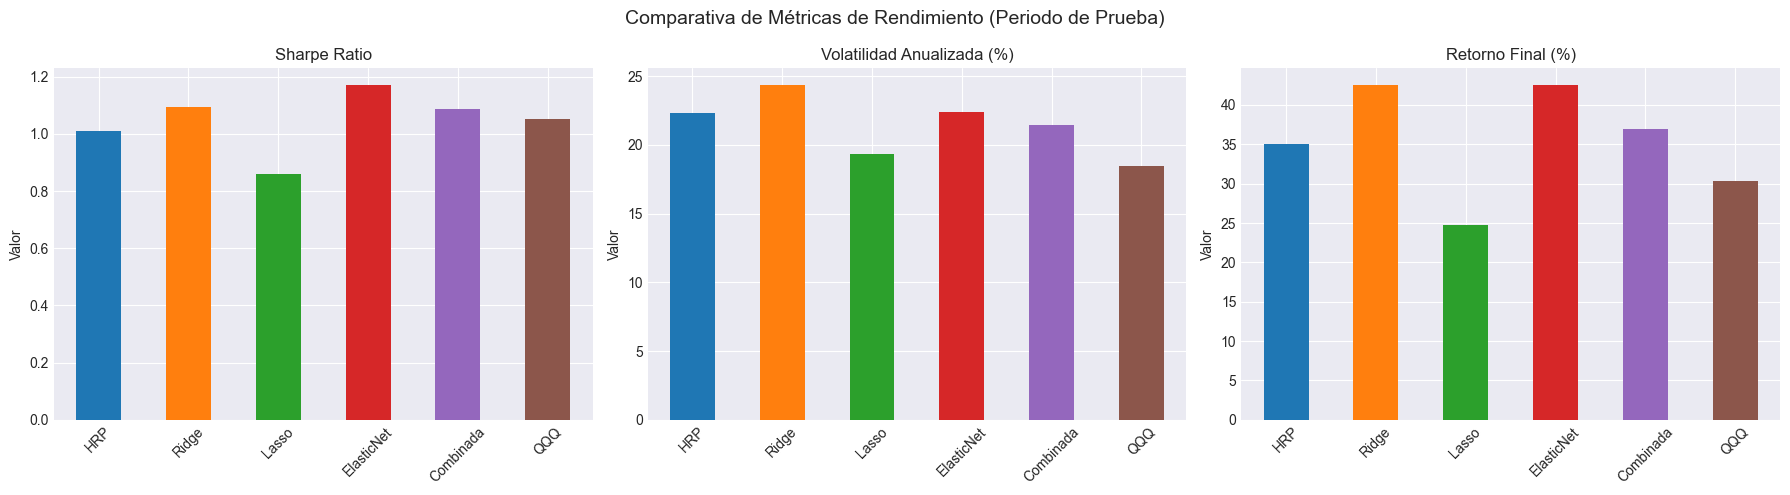

In [25]:
# Usar una paleta de colores más sobria y profesional
from matplotlib.cm import get_cmap

# Paleta más neutra/tecnológica
cmap = get_cmap("tab10")
custom_colors = [cmap(i) for i in range(len(metrics))]

# Crear gráfico de barras
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, columna in enumerate(metrics.columns):
    metrics[columna].plot(kind='bar', ax=axes[i], color=custom_colors)
    axes[i].set_title(columna)
    axes[i].set_ylabel("Valor")
    axes[i].set_xticklabels(metrics.index, rotation=45)
    axes[i].grid(True)

plt.suptitle("Comparativa de Métricas de Rendimiento (Periodo de Prueba)", fontsize=14)
plt.tight_layout()
plt.show()


<Figure size 1600x1400 with 0 Axes>

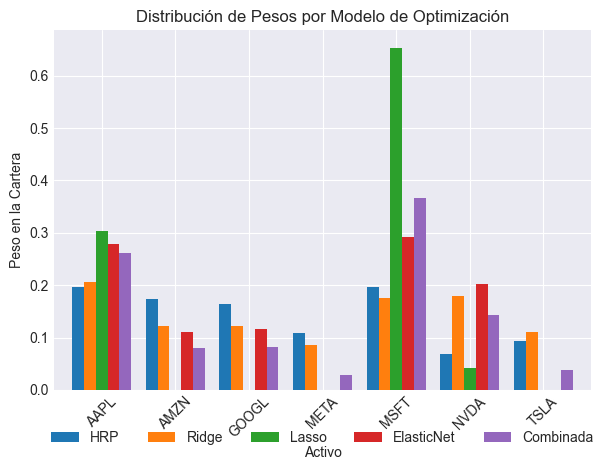

In [33]:
# Crear figura más grande y con etiquetas del eje x rotadas
plt.figure(figsize=(16, 14))
ax = weights_df.plot(kind='bar', width=0.8, color=custom_colors)
plt.title('Distribución de Pesos por Modelo de Optimización')
plt.xlabel('Activo')
plt.ylabel('Peso en la Cartera')
plt.xticks(rotation=45)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()

plt.show()



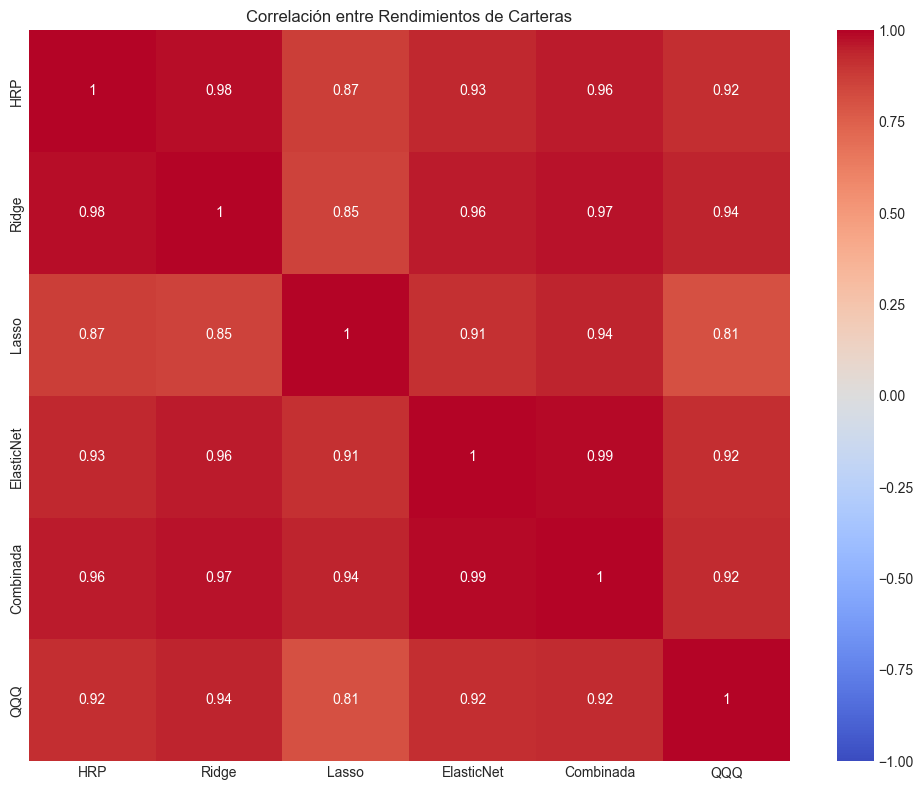

In [34]:
# Correlación entre los rendimientos de las carteras
correlation_matrix = pd.DataFrame({
    name: result['returns'] for name, result in results.items()
}).corr()



plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre Rendimientos de Carteras')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

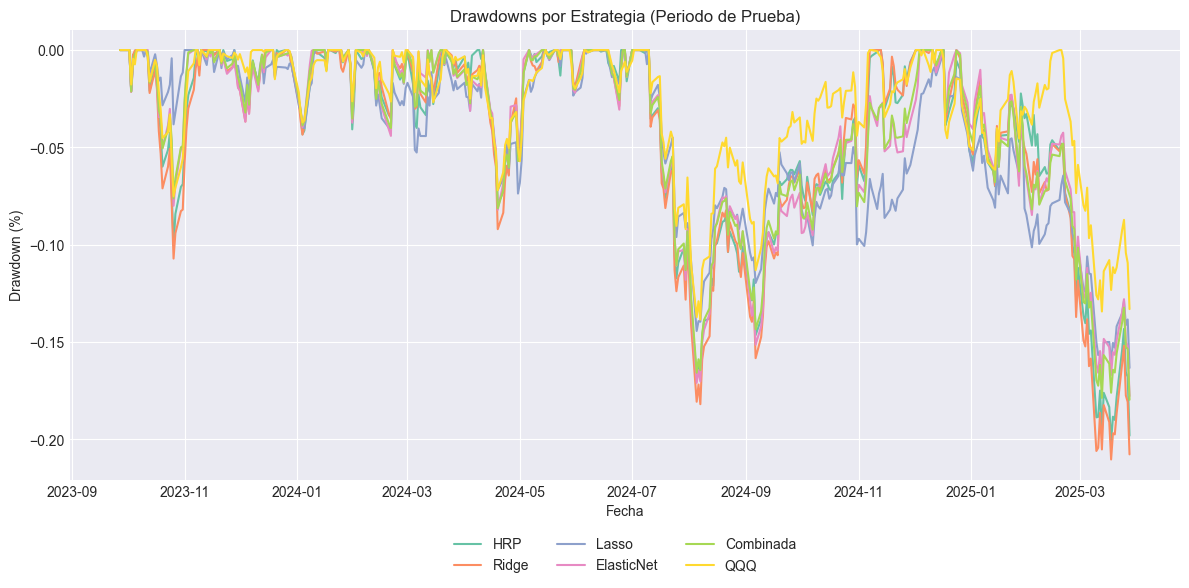

In [35]:
# Análisis de drawdowns
def calculate_drawdowns(returns):
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdowns = (cum_returns / running_max) - 1
    return drawdowns

plt.figure(figsize=(12, 6))
for name, result in results.items():
    drawdowns = calculate_drawdowns(result['returns'])
    plt.plot(drawdowns, label=name)
plt.title('Drawdowns por Estrategia (Periodo de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Drawdown (%)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.savefig('drawdowns.png')
plt.show()


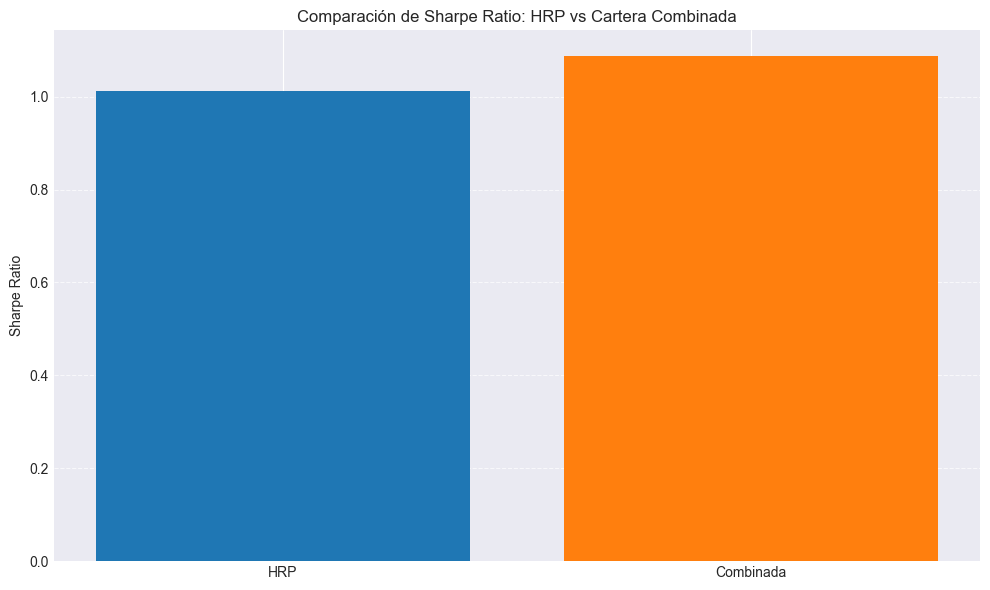

In [36]:
# Comparación entre HRP y Combinada
plt.figure(figsize=(10, 6))
plt.bar(['HRP', 'Combinada'],
        [metrics.loc['HRP', 'Sharpe Ratio'], metrics.loc['Combinada', 'Sharpe Ratio']],
        color=['#1f77b4', '#ff7f0e'])
plt.title('Comparación de Sharpe Ratio: HRP vs Cartera Combinada')
plt.ylabel('Sharpe Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('hrp_vs_combined.png')
plt.show()

<Figure size 1200x600 with 0 Axes>

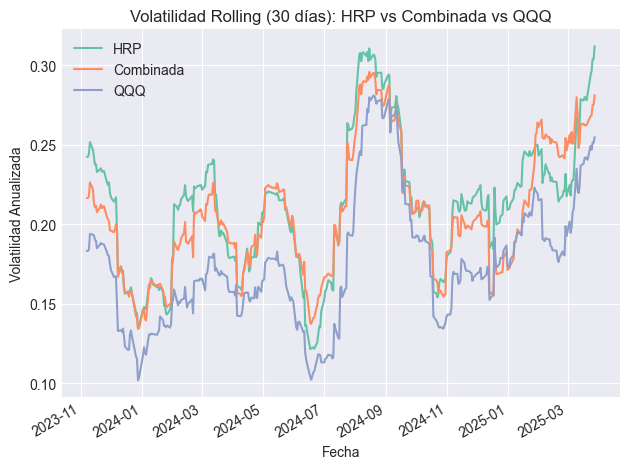

In [37]:
# Análisis de volatilidad rolling
window = 30  # 30 días
rolling_vol = pd.DataFrame({
    name: result['returns'].rolling(window=window).std() * np.sqrt(252) for name, result in results.items()
})

plt.figure(figsize=(12, 6))
rolling_vol[['HRP', 'Combinada', 'QQQ']].plot()
plt.title(f'Volatilidad Rolling ({window} días): HRP vs Combinada vs QQQ')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad Anualizada')
plt.legend()
plt.tight_layout()
plt.savefig('rolling_volatility_comparison.png')
plt.show()

In [38]:
# Resumen de resultados
print("\nResumen final:")
print(f"Período de prueba: {returns_test.index[0].strftime('%Y-%m-%d')} a {returns_test.index[-1].strftime('%Y-%m-%d')}")
print(f"Mejor Sharpe Ratio: {metrics['Sharpe Ratio'].idxmax()} ({metrics['Sharpe Ratio'].max():.2f})")
print(f"Menor Volatilidad: {metrics['Volatilidad Anualizada (%)'].idxmin()} ({metrics['Volatilidad Anualizada (%)'].min():.2f}%)")
print(f"Mayor Retorno: {metrics['Retorno Final (%)'].idxmax()} ({metrics['Retorno Final (%)'].max():.2f}%)")
print(f"\nComparación HRP vs Combinada:")
print(f"Diferencia en Sharpe: {metrics.loc['Combinada', 'Sharpe Ratio'] - metrics.loc['HRP', 'Sharpe Ratio']:.4f}")
print(f"Diferencia en Volatilidad: {metrics.loc['Combinada', 'Volatilidad Anualizada (%)'] - metrics.loc['HRP', 'Volatilidad Anualizada (%)']:.2f}%")
print(f"Diferencia en Retorno: {metrics.loc['Combinada', 'Retorno Final (%)'] - metrics.loc['HRP', 'Retorno Final (%)']:.2f}%")


Resumen final:
Período de prueba: 2023-09-27 a 2025-03-28
Mejor Sharpe Ratio: ElasticNet (1.17)
Menor Volatilidad: QQQ (18.44%)
Mayor Retorno: Ridge (42.51%)

Comparación HRP vs Combinada:
Diferencia en Sharpe: 0.0769
Diferencia en Volatilidad: -0.89%
Diferencia en Retorno: 1.91%
